In [34]:
import json
import matplotlib.pyplot as plt
import numpy as np
import re
experiments = ["codecontests", "connections", "sequences"]
ops = ["BASE", "REFLECTIVE", "ITERATIVE", "FEEDBACK","PARAPHRASE"]
tok_pattern = r"""Token checkpoint: (\w+) - Prompt tokens: (\d+), Completion tokens: (\d+)\s*.* INFO - Token checkpoint: (\w+) - Prompt tokens: (\d+), Completion tokens: (\d+)"""

all_data = {"prompts": {}, "attempts": {}, "tokens":{}}
for exp in experiments:
    for k in all_data.keys():
        all_data[k][exp] = {}
    for op in ops:
        for k in all_data.keys():
            all_data[k][exp][op] = []
        indices = [1] if op == "BASE" else [1, 2, 3]
        for rep in indices:
            with open(f"finished_experiments/{exp}{rep}_{op}/prompts.jsonl") as f:
                prompts = [json.loads(line) for line in f]
            with open(f"finished_experiments/{exp}{rep}_{op}/task_attempts.json") as f:
                task_attempts = json.load(f)
            with open(f"finished_experiments/{exp}{rep}_{op}/model_api.log") as f:
                matches = re.findall(tok_pattern, f.read())
            token_checkpoints = {}
            if len(matches) == 3:
                for m in matches:
                    for i in range(2):
                        token_checkpoints[f"{m[3*i]}{i}"] = {
                            "prompt_tokens": int(m[3*i+1]),
                            "completion_tokens": int(m[3*i+2]),
                        }
            all_data["prompts"][exp][op].append(prompts)
            all_data["attempts"][exp][op].append(task_attempts)
            all_data["tokens"][exp][op].append(token_checkpoints)

In [2]:
from textwrap import dedent
table = dedent(r"""
\begin{table}[htbp]
    \centering
    \captionsetup{font=small}
    \caption{<NAME>}  
    \label{<LABEL>}
    \renewcommand{\arraystretch}{1.4} % row spacing
    
    \begin{tabular}{|c||c|c|c|c|}
    \hline
    \rowcolor{ctulightblue}
    \textsc{Step} &
    \cellcolor{ctulightblue}\textsc{Reflective} &
    \cellcolor{ctulightblue}\textsc{Iterative} &
    \cellcolor{ctulightblue}\textsc{Feedback} &
    \cellcolor{ctulightblue}\textsc{Paraphrase} \\
    \hline

    \rowcolor{ctuorange!15}
    <DATA>
    
    \end{tabular}
\end{table}
""")

improvement exp='codecontests' op='REFLECTIVE' gen=1 is 1.4476207826020417
improvement exp='codecontests' op='ITERATIVE' gen=1 is 1.0872872551427115
improvement exp='codecontests' op='FEEDBACK' gen=1 is 1.6121781673246567
improvement exp='codecontests' op='PARAPHRASE' gen=1 is 1.357433535069485
improvement exp='codecontests' op='REFLECTIVE' gen=2 is 1.3786993380947077
improvement exp='codecontests' op='ITERATIVE' gen=2 is 1.5839324505563008
improvement exp='codecontests' op='FEEDBACK' gen=2 is 0.7126849852619542
improvement exp='codecontests' op='PARAPHRASE' gen=2 is 1.3778612299471829
improvement exp='codecontests' op='REFLECTIVE' gen=3 is 1.4627246946239187
improvement exp='codecontests' op='ITERATIVE' gen=3 is 1.1685970837558162
improvement exp='codecontests' op='FEEDBACK' gen=3 is 0.9747954233222054
improvement exp='codecontests' op='PARAPHRASE' gen=3 is 1.2102197878697527
improvement exp='codecontests' op='REFLECTIVE' gen=4 is 1.103418618804087
improvement exp='codecontests' op='I

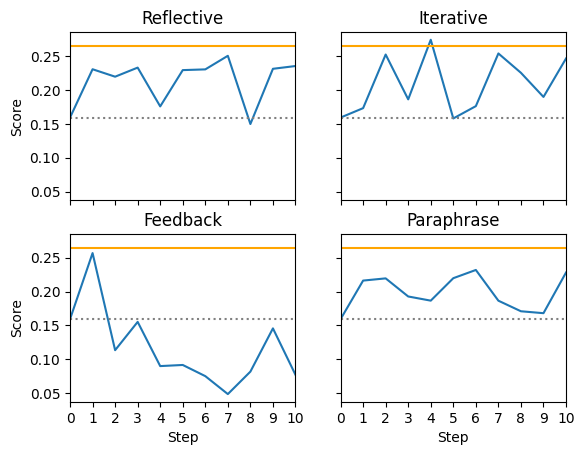

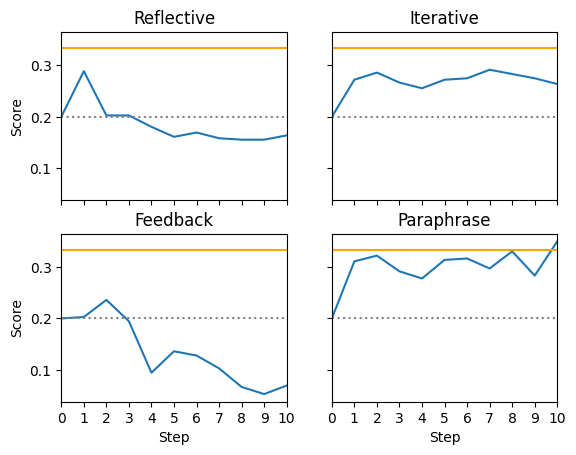

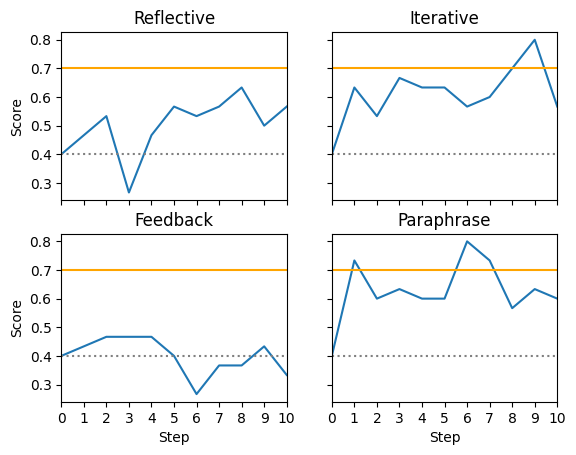

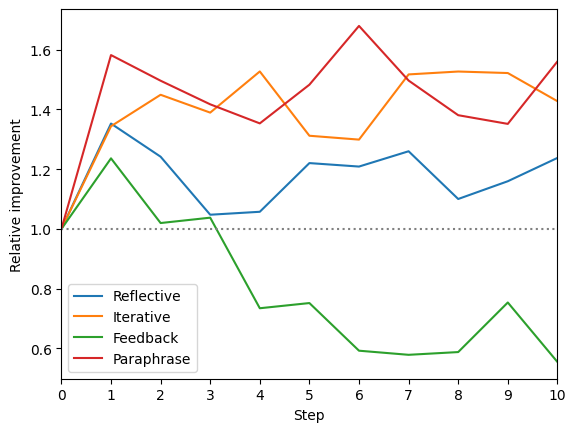

In [37]:
# all_data = dataset_name -> rep[1,2,3] -> operator -> field
import matplotlib.pyplot as plt
ops_no_base = ["REFLECTIVE", "ITERATIVE", "FEEDBACK","PARAPHRASE"]
improvements = {k: [1]+[0]*10 for k in ops_no_base}
for exp in experiments:
    data = ""
    curr_table = table[:].replace("<NAME>", f"Results for {exp}").replace("<LABEL>", f"tab:res{exp}")
    baselines = all_data["prompts"][exp]["BASE"][0]
    sorted_baselines = sorted(baselines, key = lambda p: p["test_score"], reverse=True)
    hard_baseline = sorted_baselines[0]["test_score"]
    soft_baseline = sorted_baselines[10]["test_score"]
    data = f"Baseline & {hard_baseline:.2f} & {hard_baseline:.2f} & {hard_baseline:.2f} & {hard_baseline:.2f} \\\\ \\hline\n"
    data += f"Initial & {soft_baseline:.2f} & {soft_baseline:.2f} & {soft_baseline:.2f} & {soft_baseline:.2f} \\\\ \\hline\n"
    ops_maxes = {k: [soft_baseline] for k in ops_no_base}

    for gen in range(1,11):
        data += f"${gen}$ "
        for op in ops_no_base:
            prompts = all_data["prompts"][exp][op]

            acc_max = 0
            acc_avg = 0
            for rep in [1,2,3]:
                target = list(filter(lambda p: p["gen"] == gen, prompts[rep-1]))
                scores = [p["test_score"] for p in target]
                m = max(scores)
                a = sum(scores)/len(scores)
                acc_max += m
                acc_avg += a
            gen_max = acc_max / 3
            gen_avg = acc_avg / 3
            clr = "\\cellcolor{lightgreen}" if gen_max > soft_baseline else "\\cellcolor{lightred}"
            data += f"& {clr}\\maxmean{{{gen_max:.2f}}}{{{gen_avg:.2f}}} "
            ops_maxes[op].append(gen_max)
            improvements[op][gen] += gen_max / soft_baseline
            print(f"improvement {exp=} {op=} {gen=} is {gen_max / soft_baseline}")
        data += "\\\\ \\hline\n"
    curr_table = curr_table.replace("<DATA>", data)
    #with open("tables.tex", "a+") as f:
    #   f.write(curr_table)
    fig, ax = plt.subplots(2, 2, sharex=True, sharey=True)
    gens = list(range(0, 11))
    for i in range(2):
        for j in range(2):
            op = ops_no_base[2*i+j]
            ax[i, j].plot(gens, ops_maxes[op])
            if i == 1:
                ax[i, j].set_xlabel("Step")
            ax[i, j].set_xticks(list(range(0, 11)))
            if j == 0:
                ax[i, j].set_ylabel("Score")
            ax[i, j].set_title(op.capitalize())
            ax[i, j].hlines(hard_baseline, xmin=0, xmax=10, linestyles="solid", colors="orange")
            ax[i, j].hlines(soft_baseline, xmin=0, xmax=10, linestyles="dotted",  colors="grey")
            ax[i, j].set_xbound(0, 10)
    e = "CodeContests" if exp == "codecontests" else exp.capitalize()
    #fig.suptitle(f"Operator performance on {e}")
    #fig.savefig(f"{exp}.pdf")

fig, ax = plt.subplots(1, 1)
for k, acc in improvements.items():
    v = [1] + [val/3 for val in acc[1:]]
    ax.plot(range(11), v, label=k.capitalize())
ax.set_xlabel("Step")
ax.set_ylabel("Relative improvement")    
ax.set_xticks(list(range(0, 11)))
ax.hlines(1.0, xmin=0, xmax=10, linestyles="dotted",  colors="grey")
ax.set_xbound(0, 10)
#ax.set_title("Operator effectivity")
ax.legend()
fig.savefig("relative.pdf")
    



codecontests REFLECTIVE 0 total 329157
codecontests REFLECTIVE 1 total 343114
codecontests REFLECTIVE 2 total 352957
codecontests ITERATIVE 0 total 337324
codecontests ITERATIVE 1 total 321600
codecontests ITERATIVE 2 total 322686
codecontests FEEDBACK 0 total 4332293
codecontests FEEDBACK 1 total 4022765
codecontests FEEDBACK 2 total 5091774
codecontests PARAPHRASE 0 total 303529
codecontests PARAPHRASE 1 total 281765
codecontests PARAPHRASE 2 total 285384
connections REFLECTIVE 0 total 139245
connections REFLECTIVE 1 total 138952
connections REFLECTIVE 2 total 148745
connections ITERATIVE 0 total 196931
connections ITERATIVE 1 total 171588
connections ITERATIVE 2 total 190676
connections FEEDBACK 0 total 3558151
connections FEEDBACK 1 total 3237646
connections FEEDBACK 2 total 3827530
connections PARAPHRASE 0 total 130394
connections PARAPHRASE 1 total 133822
connections PARAPHRASE 2 total 129906
sequences REFLECTIVE 0 total 167815
sequences REFLECTIVE 1 total 162503
sequences REFLEC

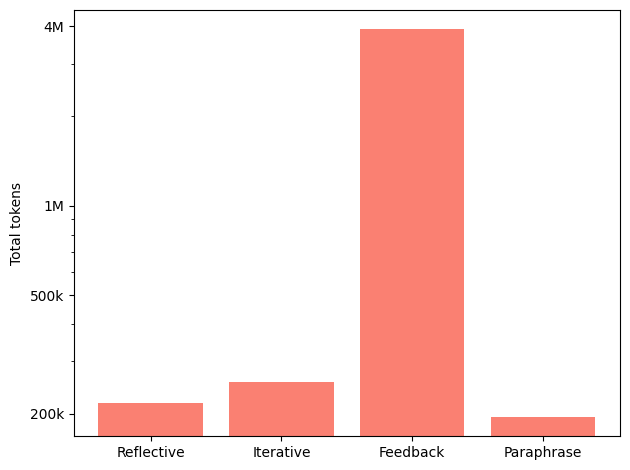

In [33]:
token_accs = {k: 0 for k in ops_no_base}
token_samples = {k: 0 for k in ops_no_base}
for exp in experiments:
    for op in ops_no_base:
        for rep in range(3):
            try:
                data = all_data["tokens"][exp][op][rep]
                acc = 0
                for match in range(2):
                    for tp in ["prompt_tokens", "completion_tokens"]:
                        acc += data[f"optim{match}"][tp]
                    #print(exp, op, rep, tp, data[tp])
                print(exp, op, rep, "total", acc)
                token_accs[op] += acc
                token_samples[op] += 1
            except Exception as e:
                print(f"{e}")
fig, ax = plt.subplots(1, 1)
x = [o.capitalize() for o in ops_no_base]
h = [v / token_samples[k] for k, v in token_accs.items()]
ax.bar(x, h, color="salmon")
ax.set_ylabel("Total tokens")
ax.set_yscale("log")
ticks = [2e5, 5e5, 1e6, 4e6]
tick_labels = ['200k', '500k', '1M', '4M']

ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)

fig.tight_layout()
#fig.show()
#ax.set_title("Token usage by operator")
fig.savefig("usage.pdf")
